# **`dbt` crash course**

https://www.youtube.com/watch?v=C6BNAfaeqXY


## **`dbt` key concepts**

- **Models**: they are **SQL files** with a **`SELECT` statement**. These models are defined in .sql files and can reference other models or tables in your DW. The names of models created by dbt are their file names.

- **Macro**: they enable **code reusability**. Using macros in dbt simplifies the process of reusing SQL code fragments across various models. Similar to functions in python.

- **Tests**. They allow to **verify** the **data quality** of your **models**. There are two primary types:   
    - **Generic tests**: **predefined tests out-of-the-box**, that you can apply across **multiple data models** 
    - **Singular tests**: **custom tests** that you develop for a **specific data model**

- **Snapshots**: they allow to **track slow changing dimensions over time**

This is the **structure** of the **dbt project initialised by default**:

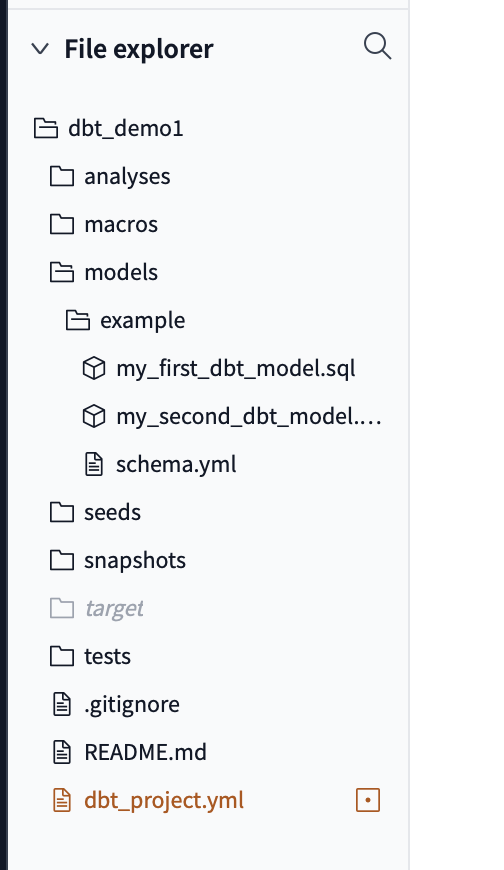

## **`dbt` configuration `yml` files**
- **`profile.yml`**: it **manages DBs connections** and contains **specific connection details** for **different environments**. This is used only with **dbt core** (but not dbt cloud)

- **`dbt_project.yml`**: it contains **settings** related to your dbt project, such as **project name** and selected **profile**. It also specifies where dbt should look for different types of files (which are the relevant directories) and the materialization settings

## **`dbt` Models**
Models are the **basic building blocks** of a **dbt project**. They are **SQL definitions**, which are then **materialized** as **tables** or **views**. If a model contains **multiple data transformations**, it can be difficult to maintain it and test it. We should separate it into **multiple model references** using the **`ref` keyword**

### **Materialization**

Materializations are **strategies for persisting dbt models** in a DW. There are **4 types** of materializations built in dbt:
- **View**: **models** are **rebuilt on each run** (default)
- **Table**: **models** are **rebuilt on each run**
- **Incremental**: **Only new/updated records** are **added** to the table
- **Ephemeral**: **CTE-based** (**no tables are added** to the database)

## **`dbt` Macros**
Macros in dbl simplify the process of **re-using SQL code fragments** across **various models**. They are similar to functions.

**Syntax** for **creating** a dbt macro:

```
{% macro macro_name(argument1, argument2, ...) %}
-- SQL logic here
{% end macro %}
```


**Syntax** for **using** a dbt macro:

```
{{macro macro_name(argument1, argument2, ...)}}
```

## **`dbt` Tests**
With dbt you can easily verify the quality of your models

**Generic tests**: they include `unique`, `not_null`, `accepted_values`. There are also **relationship tests per column** that are **defined in the `yaml` files** (e.g. `schema.yml`)

**Singular tests**: **bespoke tests**, they are defined via **sql scripts** included in the **`tests`** folder. The can be **any query**. They are **successful** if the sql scripts **do not return any rows**, else unsuccessful. 

## **`dbt` Snapshots**

Snapshots are used to **capture the changes** in the data **slow changing dimensions**. These are dimensions that change infrequently (e.g. customer address or customer phone number). Slow changing dimensions can be of **different types** (https://www.thoughtspot.com/data-trends/data-modeling/slowly-changing-dimensions-in-data-warehouse)

dbt only catches slow changing dimensions of **type 2** (https://www.phdata.io/blog/how-to-slowly-change-dimensions-with-snapshots-in-dbt/). This type involves **creating a new record in the dimension table whenever there is a change in the data**. The new record includes a **start date** for when it becomes effective and the **end date** will be a **high date** or **null** based on the design; the **old record** is marked with an **end date**. This way, **historical changes are preserved**, and you can **track the history of the data** over time.

In dbt, snapshots work according to **two strategies**, **timestamp strategy** (recommended) and **check strategy**. https://docs.getdbt.com/docs/build/snapshots